## Impl directories to analyze

In [13]:
from pathlib import Path

# Modes refer to the thing after underscore in implementations_XXX folder, see #settings 
MODES = ["noDesign", "5aspects", "human"] # , "allAtOnce", "byLayer"]
PROBLEM = "iris_recognition"
TYPE = "custom"  # either "scb" or "custom" 

if TYPE == "custom": 
    dirs = [
        Path(f"datasets/custom/problems/{PROBLEM}/implementations_{x}") for x in MODES
    ]
elif TYPE == "scb": 
    dirs = [
        Path(f"datasets/slopCodeBench/scb-problems/{PROBLEM}/implementations_{x}") for x in MODES
    ]
else: 
    raise Exception(f"Invalid problem type: {TYPE}")


# Verify if the paths exist (also verifies if the problem is valid) 
for path in dirs: 
    if not path.exists(): 
        raise Exception(f"Path does not exist: {path}")
dirs

[PosixPath('datasets/custom/problems/iris_recognition/implementations_noDesign'),
 PosixPath('datasets/custom/problems/iris_recognition/implementations_5aspects'),
 PosixPath('datasets/custom/problems/iris_recognition/implementations_human')]

## Extract the relevant metrics
metrics_dpy is in the form of `[ [{}, {}, {}...], [{}, {},...] ]` one array for one workflow mode

In [14]:
from metrics.radon.overall_metrics import get_radon_metrics
from metrics.deps_graph.overall_metrics import get_deps_graph_metrics
from metrics.designite_py.overall_metrics import get_dpy_metrics
from metrics.jscpd.overall_metrics import get_duplicates
import os 

radon_metrics = [] 
deps_graph_metrics = [] 
dpy_metrics = [] 
jscpd_metrics = [] 

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort() 

    # metrics of all checkpoints, for a single mode 
    radon_mode_metrics = []  
    deps_graph_mode_metrics = [] 
    dpy_mode_metrics = [] 
    jscpd_mode_metrics = [] 

    # walk through each checkpoint 
    for i, checkpoint_name in enumerate(checkpoint_dirs): 
        impl_dir = dirs[mode_no] / checkpoint_name
        
        radon_mode_metrics.append(
            get_radon_metrics(implementation_path=impl_dir)
        )
        deps_graph_mode_metrics.append(
            get_deps_graph_metrics(implementation_path=impl_dir)
        )
        dpy_mode_metrics.append(
            get_dpy_metrics(implementation_path=impl_dir)
        )
        jscpd_mode_metrics.append(
            get_duplicates(implementation_path=impl_dir)
        )
    
    radon_metrics.append(radon_mode_metrics)
    deps_graph_metrics.append(deps_graph_mode_metrics) 
    dpy_metrics.append(dpy_mode_metrics) 
    jscpd_metrics.append(jscpd_mode_metrics)


[GRAPH 1/6] Generating missing init.py
[GRAPH 2/6] Generating temp entrypoint file
[GRAPH 3/6] Generating dependency graph
[GRAPH 4/6] Converting the dependency graphs to JSON
Dependency graph has 2 modules.
[GRAPH 5/6] Generating visibility matrix
[GRAPH 6/6] Removing temp file
[1/2] DPy metrics
invoking license validation...
DPy version 1.7.8 Trial
Copyright (c) Designite 2026.
Current Configuration:
  Input Path: /home/bernardmoy/modular-SWE/datasets/custom/problems/iris_recognition/implementations_noDesign/checkpoint_1
  Output Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
  Output Format: json
  Configuration File: /tmp/onefile_50275_1786912143_366467/default_config.json
  Log Directory: /home/bernardmoy/modular-SWE/temp_metrics/dpy_metrics
invoking license validation...
License type: LicenseType.Trial
Parsing ...
Calculating metrics ...
Detecting code smells ...
Detecting design smells ...
Detecting architecture smells ...
Detecting machine learning smells ...


## Change coupling metrics

In [15]:
import os 
from metrics.change_coupling.overall_metrics import get_added_files, get_changed_files, get_deleted_files

for mode_no, mode in enumerate(MODES): 
    # Obtain the checkpoint directories names of the problem
    # checkpoint_1, checkpoint_2, ... checkpoint_N
    checkpoint_dirs = []
    for (root, dir, files) in os.walk(dirs[mode_no], topdown=True): 
        # only extract the top level iteration 
        checkpoint_dirs = dir 
        break 
    checkpoint_dirs.sort()  # walk through each checkpoint 

    # Walk through each checkpoint in pairs 
    for i in range(1, len(checkpoint_dirs)): 
        prev_impl_dir = dirs[mode_no] / checkpoint_dirs[i-1]
        impl_dir = dirs[mode_no] / checkpoint_dirs[i]

        # With respect to the prev impl and the current impl dir: determine the files that are added / changed / deleted 
        print(f"{prev_impl_dir}->{impl_dir}: {get_changed_files(prev_impl_dir, impl_dir)}")

datasets/custom/problems/iris_recognition/implementations_noDesign/checkpoint_1->datasets/custom/problems/iris_recognition/implementations_noDesign/checkpoint_2: ['iris.py']
datasets/custom/problems/iris_recognition/implementations_noDesign/checkpoint_2->datasets/custom/problems/iris_recognition/implementations_noDesign/checkpoint_3: ['iris.py']
datasets/custom/problems/iris_recognition/implementations_noDesign/checkpoint_3->datasets/custom/problems/iris_recognition/implementations_noDesign/checkpoint_4: ['normalizer.py', 'scanner.py', 'segmenter.py', 'iris.py']
datasets/custom/problems/iris_recognition/implementations_noDesign/checkpoint_4->datasets/custom/problems/iris_recognition/implementations_noDesign/checkpoint_5: ['iris.py']
datasets/custom/problems/iris_recognition/implementations_noDesign/checkpoint_5->datasets/custom/problems/iris_recognition/implementations_noDesign/checkpoint_6: ['iris.py']
datasets/custom/problems/iris_recognition/implementations_5aspects/checkpoint_1->da

## Logical lines of code

[[209, 511, 779, 1049, 1175, 1323], [241, 649, 962, 1222, 1468, 1624], [282, 443, 831]]


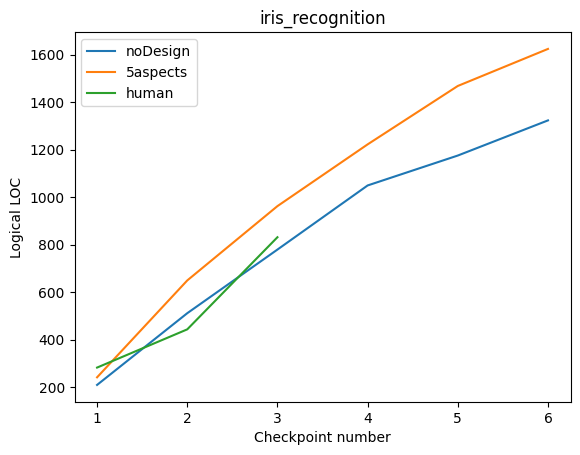

In [16]:
lloc = [[x["lloc"] for x in entry] for entry in radon_metrics]
print(lloc) 

from matplotlib import pyplot as plt 

for i, entry in enumerate(lloc): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = entry
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Logical LOC")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Functions with high CC | Max LOC function | Classes with high fan out 

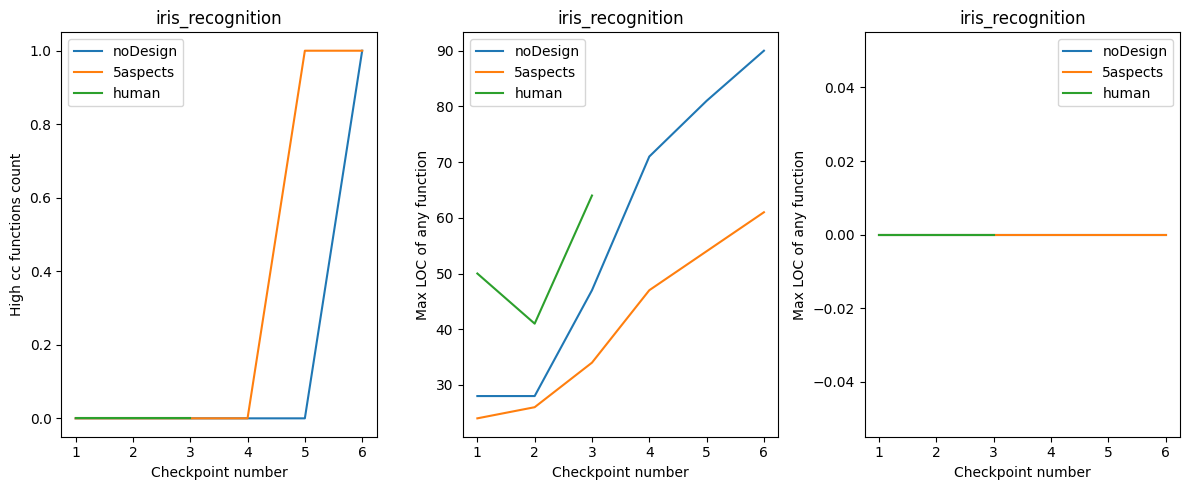

In [17]:
high_cc = [[x["high_cc_functions_count"] for x in entry] for entry in dpy_metrics]
function_max_loc = [[x["function_max_loc"] for x in entry] for entry in dpy_metrics]
high_fan_out = [[x["high_fan_out_classes_count"] for x in entry] for entry in dpy_metrics]

from matplotlib import pyplot as plt 

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(12, 5))

for i, entry in enumerate(high_cc):
    x = range(1, len(entry) + 1) 
    y = entry
    ax1.plot(x, y, label=MODES[i])
ax1.set_xlabel("Checkpoint number")
ax1.set_ylabel("High cc functions count")
ax1.set_title(PROBLEM)
ax1.legend()

for i, entry in enumerate(function_max_loc):
    x = range(1, len(entry) + 1)
    y = entry
    ax2.plot(x, y, label=MODES[i])
ax2.set_xlabel("Checkpoint number")
ax2.set_ylabel("Max LOC of any function")
ax2.set_title(PROBLEM)
ax2.legend()

for i, entry in enumerate(high_fan_out):
    x = range(1, len(entry) + 1)
    y = entry
    ax3.plot(x, y, label=MODES[i])
ax3.set_xlabel("Checkpoint number")
ax3.set_ylabel("Max LOC of any function")
ax3.set_title(PROBLEM)
ax3.legend()

plt.tight_layout()
plt.show()

## Maintainability index (Weighted)

[[38.99069027715363, 25.230150300314865, 22.831597232711097, 20.77813396690214, 21.01134059659807, 20.842061694100007], [54.78959597796359, 51.16304481245106, 51.20369979740536, 48.38059694510919, 46.74617486078123, 45.961056380290074], [49.54734690174188, 53.69381991665843, 54.590762941882154]]


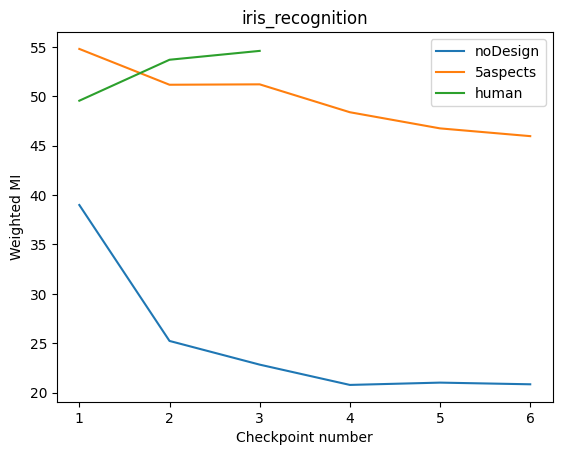

In [18]:
mi = [[x["weighted_maintainability_index"] for x in entry] for entry in radon_metrics]
print(mi) 

from matplotlib import pyplot as plt 

for i, entry in enumerate(mi): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = entry
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Weighted MI")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Duplicated lines percentage

[[0.0, 0.0, 0.014925373134328356, 0.015703869882220976, 0.013487475915221581, 0.01202749140893471], [0.0, 0.0, 0.007702182284980746, 0.0, 0.0, 0.0], [0.009881422924901186, 0.01257861635220126, 0.014350945857795172]]


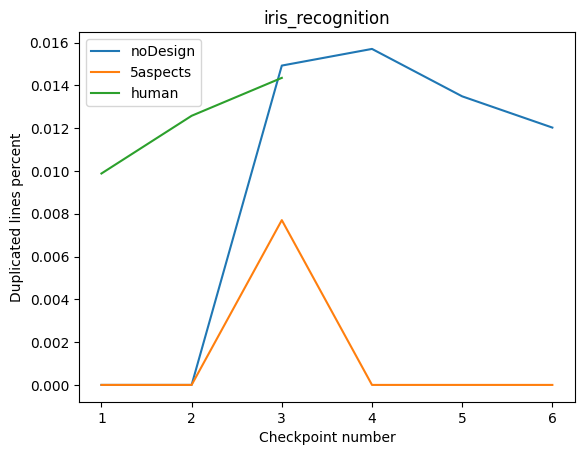

In [19]:
dup = [[x["lines"] for x in entry] for entry in jscpd_metrics]
print(dup) 

from matplotlib import pyplot as plt 

for i, entry in enumerate(dup): 
    x = range(1, len(entry)+1)  # make the x axis 1 indexed 
    y = entry
    plt.plot(x, y, label=MODES[i]) # the label is the workflow mode of the same index 
plt.xlabel("Checkpoint number")
plt.ylabel("Duplicated lines percent")
plt.title(PROBLEM) 

plt.legend() 
plt.show() 

## Whether graph has cycles

In [20]:
for i, entry in enumerate(deps_graph_metrics): 
    print(f"{MODES[i]}: {[x["has_cycles"] for x in entry]}")

noDesign: [False, False, False, False, False, False]
5aspects: [False, False, False, False, False, False]
human: [False, False, False]


## Propagation cost (and the number of modules)

[[0.75, 0.5555555555555556, 0.4375, 0.36, 0.3055555555555556, 0.3469387755102041], [0.34375, 0.1775, 0.1875, 0.11678200692041522, 0.11080332409972299, 0.10767400356930398], [0.3125, 0.296875, 0.19771071800208118]]


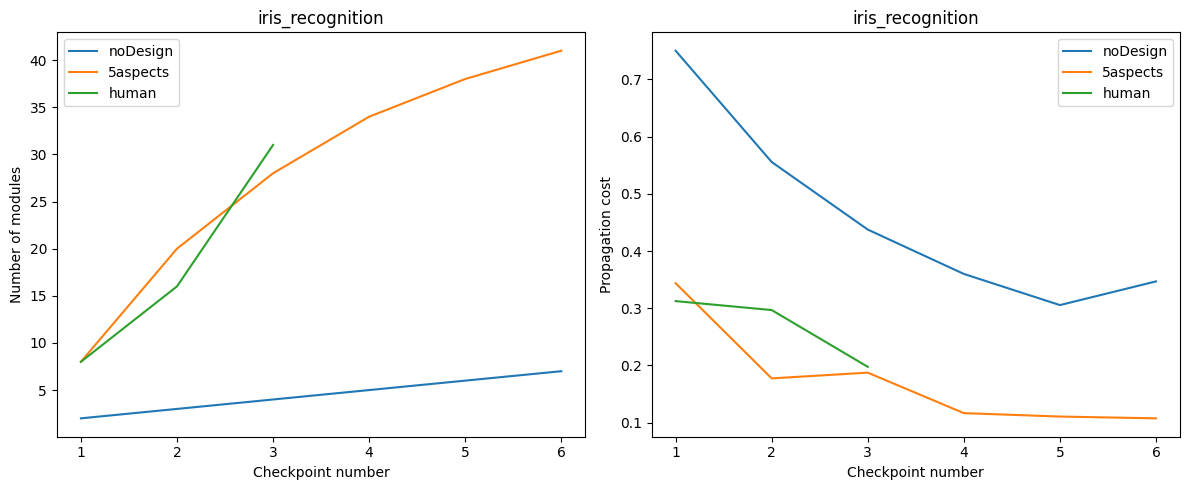

In [21]:
ns = [[x["number_of_modules"] for x in entry] for entry in deps_graph_metrics]
pc = [[x["propagation_cost"] for x in entry] for entry in deps_graph_metrics]
print(pc) 

from matplotlib import pyplot as plt 

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

for i, entry in enumerate(ns):
    x = range(1, len(entry) + 1) 
    y = entry
    ax1.plot(x, y, label=MODES[i])
ax1.set_xlabel("Checkpoint number")
ax1.set_ylabel("Number of modules")
ax1.set_title(PROBLEM)
ax1.legend()

for i, entry in enumerate(pc):
    x = range(1, len(entry) + 1)
    y = entry
    ax2.plot(x, y, label=MODES[i])
ax2.set_xlabel("Checkpoint number")
ax2.set_ylabel("Propagation cost")
ax2.set_title(PROBLEM)
ax2.legend()

plt.tight_layout()
plt.show()

## Spider diagrams (test) 

## 

In [22]:
noDesign = {
    "Readability": {
        "score": 3,
        "comments": (
            "Most function and module names are clear, and many methods are short enough to "
            "follow, especially in http_service, matcher, and request_context. Readability drops "
            "because the design hides important behavior behind large dynamically typed modules: "
            "template_engine is a 600 LOC parser/evaluator with 94 methods and WMC 190, and "
            "mock_loader spreads loading, validation, inheritance resolution, template "
            "registration, and body file expansion across 24 methods. The action system also "
            "relies on string-dispatched dict shapes such as sleep, redis, send_http, and "
            "reply_http, which makes control flow less self-evident than typed interfaces."
        ),
    },
    "Simplicity": {
        "score": 2,
        "comments": (
            "Complexity is concentrated in a few poorly factored areas rather than being intrinsic "
            "to the problem. template_engine combines tokenization, AST construction, expression "
            "parsing, evaluation, truthiness rules, builtin functions, and registry concerns in one "
            "module; metrics confirm this with WMC 190 and functions like tokenize_template at CC 9. "
            "mock_loader also mixes multiple responsibilities and has branching hotspots such as "
            "merge_objects (CC 12) and parse_behavior (CC 10). The result is a system that works, "
            "but important behavior depends on custom DSL and schema logic that is harder to reason "
            "about than the HTTP mocking problem itself requires."
        ),
    },
    "Maintainability": {
        "score": 3,
        "comments": (
            "The codebase has a usable top-level separation between HTTP serving, matching, action "
            "execution, loading, templating, and Redis access, so many edits remain localized. "
            "However, maintainability is weakened by shared implicit contracts across modules: "
            "template variable names are hard-coded in request_context, interpreted in "
            "template_engine, and relied on by matcher, actions, and loaded YAML behaviors; action "
            "payload formats are also coupled across mock_loader, actions, and mock files. That "
            "means changes to the template DSL or action schema are likely to require coordinated "
            "edits across several files even though day-to-day fixes in narrower modules should "
            "stay manageable."
        ),
    },
    "Modularity": {
        "score": 2,
        "comments": (
            "Several modules have clear single responsibilities, but the main hotspots do not. "
            "mock_loader is insufficiently modularized by both direct observation and metrics "
            "(LOC 176, NOM/NOPM 24, WMC 74): it performs file discovery, YAML parsing, validation, "
            "duplicate resolution, inheritance merging, template registration, and behavior "
            "construction. template_engine is a stronger violation, bundling data wrappers, node "
            "types, parser stages, evaluator logic, collection semantics, and builtin functions in "
            "one 600 LOC module with insufficient modularization reported and LCOM 0.37. These are "
            "present design problems in the current code, not hypothetical future concerns."
        ),
    },
    "Reusability": {
        "score": 3,
        "comments": (
            "There is some reusable structure: the Redis backend is exposed through a stable "
            "execute interface, the HTTP response object is shared cleanly, and helper functions "
            "such as header rendering and path matching are factored out instead of duplicated. "
            "Reuse is limited, though, because major pieces are tightly shaped around this specific "
            "app: template_engine depends on global template/function registries and custom DSL "
            "semantics, request_context bakes in many alias names for that DSL, and action execution "
            "is driven by hard-coded dict keys instead of extensible objects or handlers. "
            "Duplication is not the main issue here; constrained, application-specific abstractions "
            "are."
        ),
    },
}

five_aspects = {
    "Readability": {
        "score": 4,
        "comments": (
            "Most modules are short and purpose-named, with straightforward dataclasses and "
            "helpers that make the request-matching, loading, and runtime setup paths easy to "
            "follow. The main readability cost is concentrated in the templating path, where "
            "TemplateRenderer._render_section and template_parser.extract_control_blocks encode "
            "mini-language control flow and token rules in dense loops and conditionals; the "
            "function metrics support this with CC 8 on both and 31/29 LOC respectively. Long-line "
            "smells in action_validation.py and logging.py add minor friction, but the overall "
            "codebase remains understandable."
        ),
    },
    "Simplicity": {
        "score": 3,
        "comments": (
            "Most functions are simple and narrowly scoped, but the template and validation "
            "subsystems carry non-trivial incidental complexity. "
            "validation._validate_optional_shapes reaches CC 10, template_parser.split_tokens and "
            "template_engine.TemplateRenderer._render_section are both CC 8, and _merge_data in "
            "behavior inheritance is another branch-heavy rule combiner. This complexity is "
            "somewhat justified by parsing and templating requirements, yet it still creates a few "
            "rule engines that are harder to reason about than the surrounding code."
        ),
    },
    "Maintainability": {
        "score": 3,
        "comments": (
            "Separation of concerns is generally clear, but meaningful changes to behavior "
            "definition or templating semantics will ripple across multiple modules such as "
            "validation, action_validation, template_engine, template_expression, template_parser, "
            "and the function registries. The architecture metrics flag the single hmock_core "
            "component as both a god component and feature-concentrated, which overstates the "
            "issue somewhat because many files are small, but it still reflects that the package "
            "boundary does not isolate subsystems strongly. Shared abstractions like AppRuntime, "
            "RedisBackend, and TemplateRegistry help, yet the central parsing/rendering contract "
            "remains spread across several cooperating files."
        ),
    },
    "Modularity": {
        "score": 4,
        "comments": (
            "At the module level, responsibilities are mostly distinct: HTTP serving, matching, "
            "action execution, validation, inheritance, runtime construction, and backend access "
            "are separated cleanly. The design smells for multifaceted abstraction are limited and "
            "relatively weak compared with the observed structure, though template_expression does "
            "show feature envy around context lookup and some modules such as logging and "
            "validation_helpers group a few unrelated utilities. Overall the code is modular in "
            "practice, with only the templating subsystem behaving as a tightly coupled cluster "
            "rather than fully independent pieces."
        ),
    },
    "Reusability": {
        "score": 4,
        "comments": (
            "The implementation factors reusable behavior into small helpers and abstractions: "
            "datamodels are shared cleanly, Redis access is hidden behind a protocol/factory split, "
            "body loading and validation helpers avoid repetition, and template functions are "
            "registry-driven. There is some localized duplication in how template rendering is "
            "invoked and how rendered headers are assembled across action execution and outbound "
            "HTTP, so reuse is not maximized. Still, the current structure supports extension "
            "better than a one-off implementation and avoids broad duplicated logic across modules."
        ),
    },
}

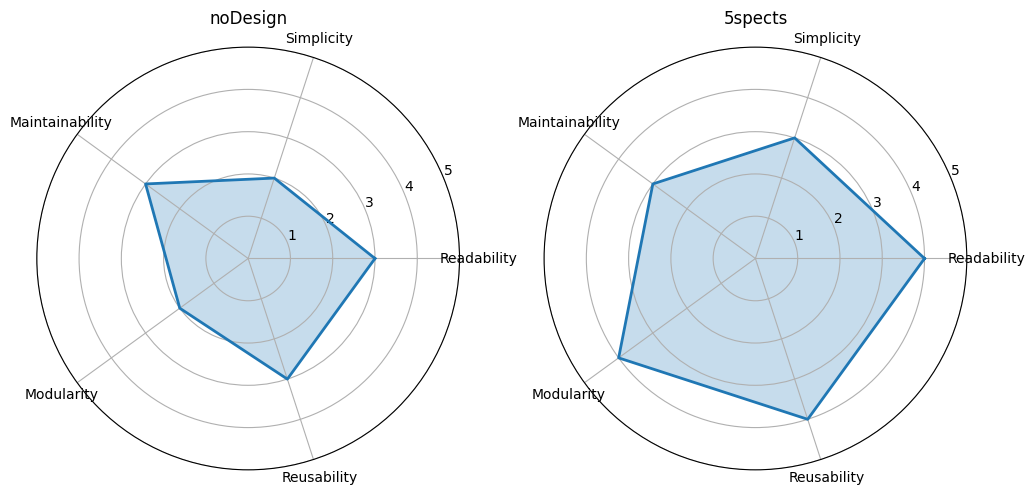

In [23]:
import matplotlib.pyplot as plt
import numpy as np

# Data
categories = ["Readability", "Simplicity", "Maintainability", "Modularity", "Reusability"]
values_noDesign = [3,2,3,2,3]
values_5aspects = [4,3,3,4,4]

# Number of variables
N = len(categories)

# Compute angle for each axis
angles = [n / float(N) * 2 * np.pi for n in range(N)]
angles += angles[:1]  # complete the loop

# Values also need to loop back to the first point
# (Append the first value to the end) 
values_noDesign += values_noDesign[:1]
values_5aspects += values_5aspects[:1]

# Create the plot
fig, (ax1, ax2) = plt.subplots(1,2,figsize=(12, 6), subplot_kw=dict(polar=True))

# Draw the outline and fill
ax1.plot(angles, values_noDesign, linewidth=2, linestyle='solid')
ax1.fill(angles, values_noDesign, alpha=0.25)

# Set category labels
ax1.set_xticks(angles[:-1])
ax1.set_xticklabels(categories)

# Optional: set y-axis limits and gridlines
ax1.set_ylim(0, 5)
ax1.set_yticks([1, 2, 3, 4, 5])

ax1.set_title("noDesign")

# Draw the outline and fill
ax2.plot(angles, values_5aspects, linewidth=2, linestyle='solid')
ax2.fill(angles, values_5aspects, alpha=0.25)

# Set category labels
ax2.set_xticks(angles[:-1])
ax2.set_xticklabels(categories)

# Optional: set y-axis limits and gridlines
ax2.set_ylim(0, 5)
ax2.set_yticks([1, 2, 3, 4, 5])

ax2.set_title("5spects")

plt.show()